In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from input_pipeline import preprocess_dataset, mask_dataset, batch_sampler
from models.median_baseline import median_baseline
import xarray as xr
import jax.numpy as jnp
import jax
import chex
import numpy as np
import flax
import rich
import flax.linen as nn
import optax

### Load, Normalization & Masking

In [3]:
ds = xr.load_dataarray('../data/SiC_19x10x3.nc')
filtered_ds = preprocess_dataset(ds, verbose = True)
mask_window: tuple = (1525, 1650)
attn_mask = ~(
        (filtered_ds.wave_number < mask_window[1]) & (filtered_ds.wave_number > mask_window[0])
    ).values
masked_ds = mask_dataset(filtered_ds, mask_window=mask_window)

Dropped 0 spectra


In [98]:
# Transformer model. See "Formal algorithms for transformers" [arXiv:2207.09238 [cs.LG]] and "On Layer Normalization in the Transformer Architecture" [arXiv:2002.04745 [cs.LG]] and "An introduction to transformers" [arXiv:2304.10557 [cs.LG]].

class LinearProjection(nn.Module):
    """Linear embedding projection"""
    embedding_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.embedding_dim, use_bias=True)(x)
        return x
    
def test_LinearProjection():
    """Test LinearProjection"""
    x = np.random.randn(1, 2, 3, 100)
    model = LinearProjection(128)
    variables = model.init(jax.random.PRNGKey(0), x)
    y = model.apply(variables, x)
    chex.assert_shape(y, (1,2,3,128))
    chex.assert_shape(variables['params']['Dense_0']['kernel'], (100, 128))
test_LinearProjection()

class FFBlock(nn.Module):
    """Feed-forward block for transformer model"""
    embedding_dim: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        x = nn.Dense(4*self.embedding_dim)(x)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic = not training)(x)
        x = nn.Dense(self.embedding_dim)(x)
        return x

class TransformerEncoderLayer(nn.Module):
    """Transformer encoder layer"""
    embedding_dim: int
    num_heads: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, attn_mask, training: bool):
        # Multi-head attention
        x_norm = nn.LayerNorm()(x)
        x_norm = nn.MultiHeadDotProductAttention(
            num_heads = self.num_heads,
            qkv_features = self.embedding_dim
        )(x_norm, deterministic = not training)
        x = x_norm
        #x = x + nn.Dense(self.embedding_dim)(x_norm) # Residual connection
        x_norm = nn.LayerNorm()(x)
        x_norm = FFBlock(self.embedding_dim, self.dropout_rate)(x_norm, training = training)
        x = x + nn.Dense(self.embedding_dim)(x_norm)
        return x
    
class SpectraFormer(nn.Module):
    embedding_dim: int
    num_heads: int
    num_layers: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, counts, wave_number, wave_number_mask, training: bool = True):
        #wave_number_mask is a 1D boolean array of shape num_wave_numbers
        emb_counts = LinearProjection(self.embedding_dim)(counts) # [batch_size, num_wave_numbers, 1]
        emb_wave_number = LinearProjection(self.embedding_dim)(wave_number) # [num_wave_numbers, 1]
        x = emb_counts + emb_wave_number # [batch_size, num_wave_numbers, embedding_dim]
        attn_mask = nn.make_attention_mask(wave_number_mask, wave_number_mask, extra_batch_dims=x.ndim - 2)
        for _ in range(self.num_layers):
            x = TransformerEncoderLayer(self.embedding_dim, self.num_heads, self.dropout_rate)(x, attn_mask, training = training)
        x = nn.LayerNorm()(x)
        x = nn.Dense(1)(x)
        return x

In [128]:
from flax.training.train_state import TrainState

In [129]:
@jax.jit
def train_step(state: TrainState, batch, dropout_key):
  dropout_train_key = jax.random.fold_in(key=dropout_key, data=state.step)
  def loss_fn(params):
    pred_spectra = state.apply_fn(
      {'params': params},
      batch['masked_spectra'], batch['wave_number'], attn_mask,
      training=False, # Disable dropout for the moment
      rngs={'dropout': dropout_train_key}
      )
    loss = optax.squared_error(pred_spectra, batch['spectra']).mean()
    return loss
  grad_fn = jax.value_and_grad(loss_fn)
  loss, grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss

In [144]:
model = SpectraFormer(embedding_dim = 32, num_heads = 4, num_layers = 4)
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

dummy_batch = next(batch_sampler(filtered_ds, masked_ds))
variables = model.init(params_key, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'], attn_mask, training = False)
params = variables['params']

state = TrainState.create(
  apply_fn=jax.jit(model.apply, static_argnames=('training', 'capture_intermediates')),
  params=params,
  tx=optax.adam(1e-4)
)

from tqdm import tqdm
n_epochs = 150
train_loss = []

In [145]:
tabulate_fn = nn.tabulate(model, jax.random.key(0), depth = 1, console_kwargs={'force_jupyter': True})

In [146]:
print(tabulate_fn(dummy_batch['masked_spectra'][0], dummy_batch['wave_number'], attn_mask, training = False))

                                               SpectraFormer Summary                                               
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module                ┃ inputs                ┃ outputs          ┃ params               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ SpectraFormer         │ - float32[1015,1]     │ float32[1015,1]  │                      │
│                       │                       │ - float32[1015,1]     │                  │                      │
│                       │                       │ - bool[1015]          │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_0    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 64 (256 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_1    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 64 (256 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 13,760 (55.0 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 13,760 (55.0 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 13,760 (55.0 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 13,760 (55.0 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LayerNorm_0           │ LayerNorm             │ float32[1015,32]      │ float32[1015,32] │ bias: float32[32]    │
│                       │                       │       

In [147]:
test_batch = next(batch_sampler(filtered_ds, masked_ds, batch_size = 1))

In [148]:
import matplotlib.pyplot as plt

def plot_intermediates(batch, state):
    wave_number = batch['wave_number'] * 800 + 2000
    out, intermediates = state.apply_fn({'params': state.params}, batch['masked_spectra'], batch['wave_number'], attn_mask, training = False, capture_intermediates=True)
    intermediates = intermediates['intermediates']
    emb_counts = intermediates['LinearProjection_0']['__call__'][0]
    emb_wave_number = intermediates['LinearProjection_1']['__call__'][0]
    embedding = emb_counts + emb_wave_number

    EncoderBlock_0 = intermediates['TransformerEncoderLayer_0']['__call__'][0]
    EncoderBlock_1 = intermediates['TransformerEncoderLayer_1']['__call__'][0]
    EncoderBlock_2 = intermediates['TransformerEncoderLayer_2']['__call__'][0]


    fig, ax = plt.subplots(3, 3, figsize = (15, 15))
    ax[0, 0].plot(wave_number,np.squeeze(emb_counts))
    ax[0, 0].set_title('Counts embedding')
    ax[0, 0].margins(x= 0)
    ax[0, 1].plot(wave_number, np.squeeze(emb_wave_number))
    ax[0, 1].set_title('Wave number embedding')
    ax[0, 1].margins(x= 0)
    ax[0, 2].plot(wave_number, np.squeeze(embedding))
    ax[0, 2].set_title('Summed embedding')
    ax[0, 2].margins(x= 0)
    ax[1, 0].plot(wave_number, np.squeeze(EncoderBlock_0))
    ax[1, 0].set_title('Encoder block 0')
    ax[1, 0].margins(x= 0)
    ax[1, 1].plot(wave_number, np.squeeze(EncoderBlock_1))
    ax[1, 1].set_title('Encoder block 1')
    ax[1, 1].margins(x= 0)
    ax[1, 2].plot(wave_number, np.squeeze(EncoderBlock_2))
    ax[1, 2].set_title('Encoder block 2')
    ax[1, 2].margins(x= 0)
    ax[2, 0].plot(wave_number, np.squeeze(batch['spectra']), label = 'Target')
    ax[2, 0].plot(wave_number, np.squeeze(out), label = 'Output')
    ax[2, 0].axvline(x = mask_window[0], color = 'k', linestyle = '--', alpha=0.5)
    ax[2, 0].axvline(x = mask_window[1], color = 'k', linestyle = '--', alpha=0.5)
    ax[2, 0].legend(frameon = False)
    ax[2, 0].set_title('Output')
    ax[2, 0].margins(x= 0)
    plt.show()


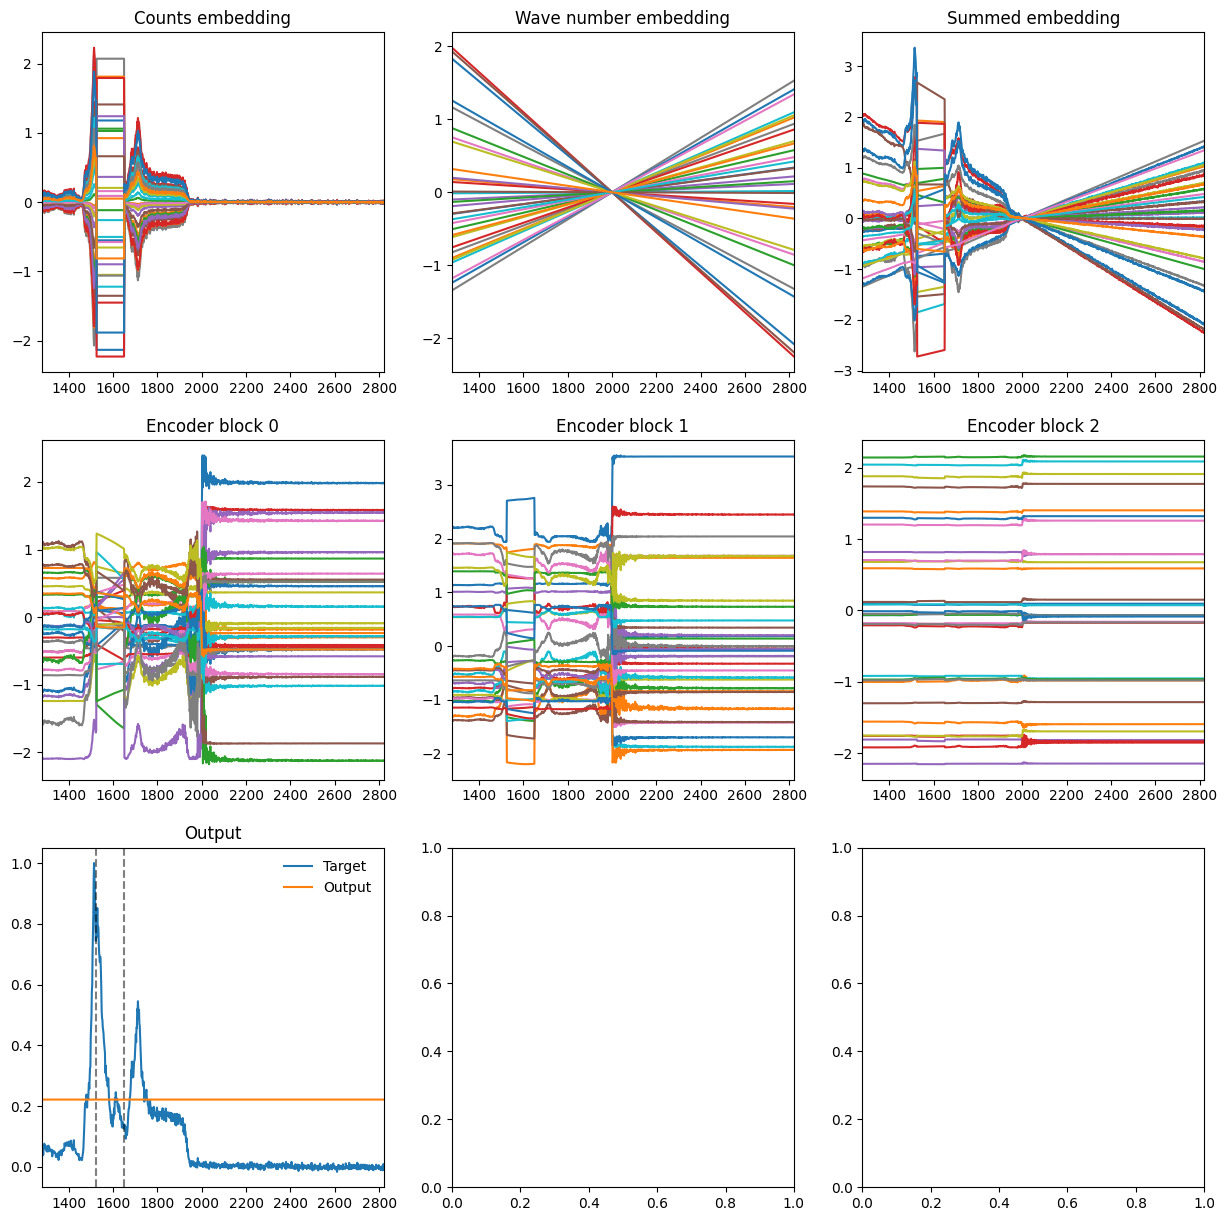

In [149]:
plot_intermediates(test_batch, state)

In [150]:
for epoch in tqdm(range(n_epochs)):
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = 32, shuffle = True, drop_last = True, rng_seed = epoch)
    for batch in train_iter:
        state, _loss = train_step(state, batch, dropout_key)
        train_loss.append(_loss.item())

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [03:12<00:00,  1.29s/it]


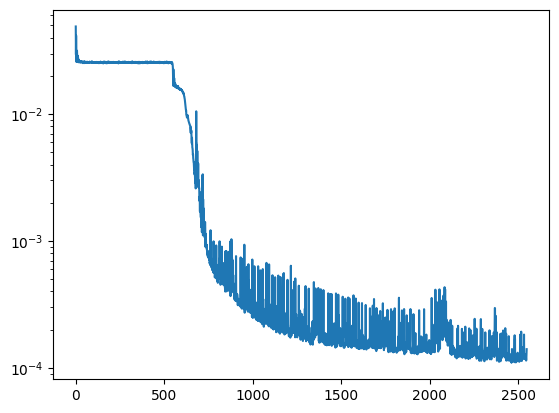

In [151]:
import matplotlib.pyplot as plt
plt.plot(train_loss)
plt.yscale('log')

In [152]:
def predict(apply_fn, params, spectra, wave_number):
    import pandas as pd
    predicted_SiC = apply_fn(params, spectra, wave_number, attn_mask, training = False)
    pred_Graphene = spectra - predicted_SiC
    res = {k: v[:, 0] for k, v in {'Predicted SiC': predicted_SiC, 'Diff': pred_Graphene, 'Original': spectra, 'Wave number': wave_number}.items()}
    return pd.DataFrame(res)

In [153]:
result = predict(state.apply_fn, {'params': state.params}, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'])

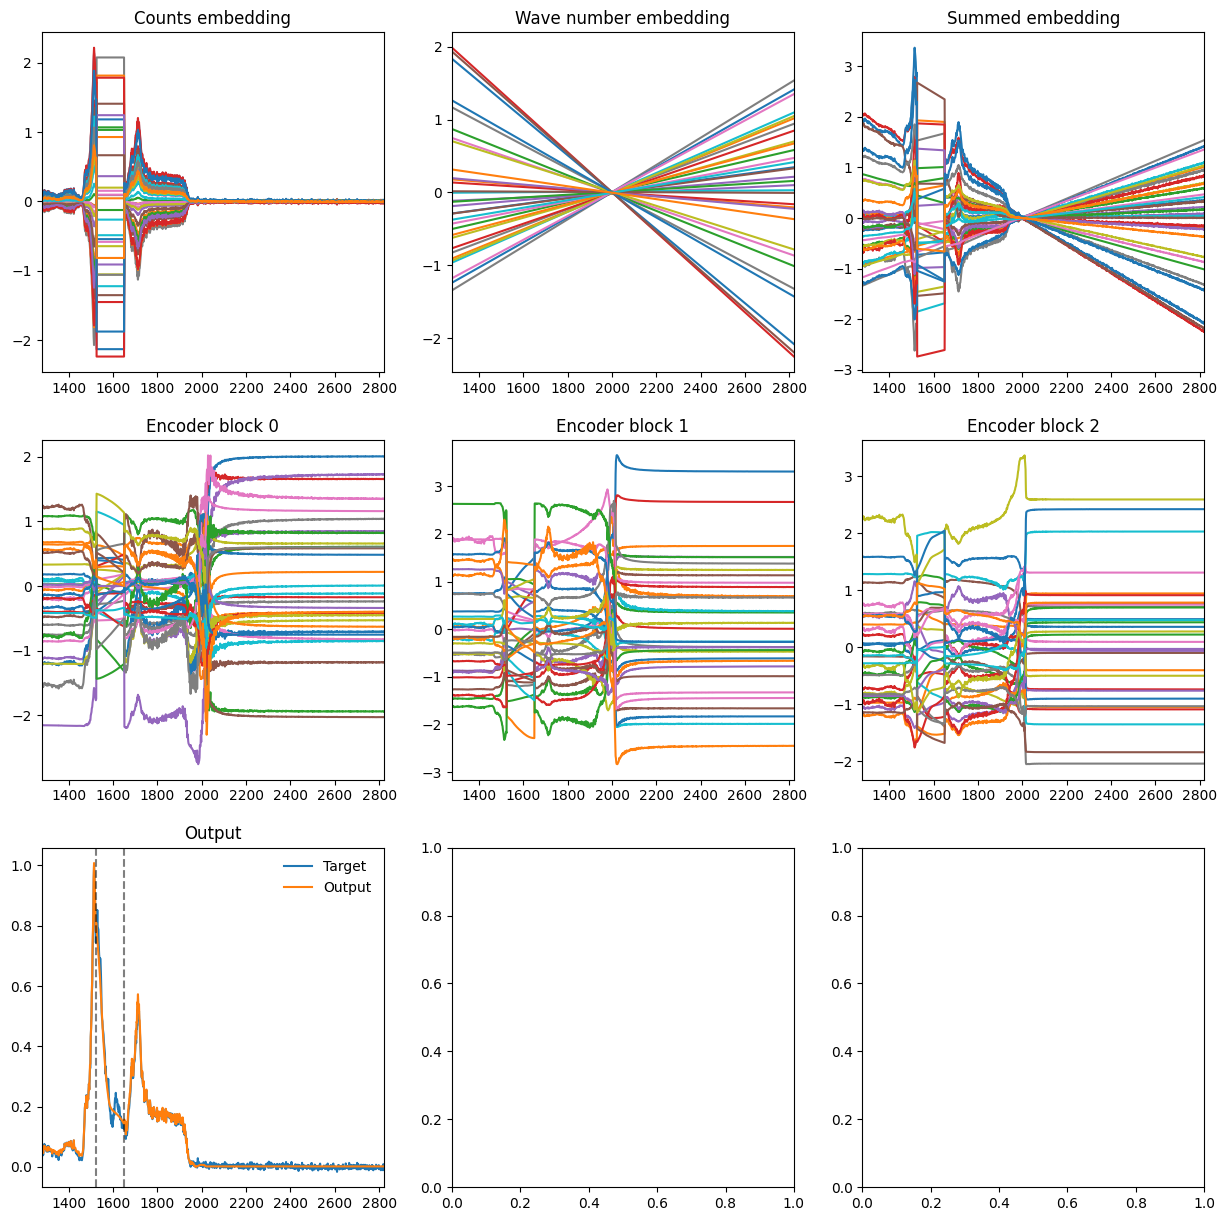

In [154]:
plot_intermediates(test_batch, state)

<Axes: xlabel='Wave number'>

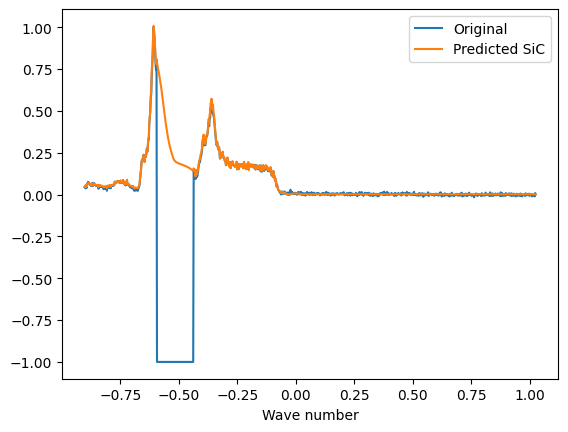

In [155]:
result.plot(x="Wave number", y=["Original", "Predicted SiC"])

In [156]:
from pathlib import Path
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()

ckpt_dir = Path('../checkpoints/SpectraFormer').resolve()
checkpointer.save(ckpt_dir / '20Feb24', state)

In [9]:
from time import perf_counter

# Measure throughput at different batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256]

for batch_size in batch_sizes:
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
    rng = jax.random.PRNGKey(0)
    rng, init_rng = jax.random.split(rng)
    batch = next(train_iter)
    variables = model.init(init_rng, counts = batch['masked_spectra'][0], wave_number = batch['wave_number'][0], training = False)
    # Warmup
    apply_fn = jax.jit(model.apply, static_argnames='training')
    apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
    
    # Measure throughput
    times = []
    for batch in train_iter:
        _dt = perf_counter()
        out = apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
        _dt = perf_counter() - _dt
        times.append(_dt)
    times = np.array(times)
    print(f"Batch size: {batch_size}, throughput: {batch_size / times.mean():.0f} samples/s")

Batch size: 8, throughput: 18170 samples/s
Batch size: 16, throughput: 29596 samples/s
Batch size: 32, throughput: 17774 samples/s
Batch size: 64, throughput: 16471 samples/s
Batch size: 128, throughput: 13481 samples/s
Batch size: 256, throughput: 19556 samples/s
